In [3]:
import os

os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.environ["TORCH_USE_CUDA_DSA"] = "1"
try:
    from core.raft_stereo import RAFTStereo
except ImportError:
    import os

    os.chdir("/RAFT-Stereo")
    from core.raft_stereo import RAFTStereo

FRPASS = "frames_cleanpass"
from train_fusion.dataloader import StereoDataset, StereoDatasetArgs

import torch
from torch import nn
import numpy as np
from torch.utils.data import DataLoader
from fusion_args import FusionArgs


#http://127.0.0.1:8888/?token=27995db2605ae38c6cbab002e0b2fdcace4cf201dccfa264

In [4]:
from myutils.hy5py import calibration_property, get_frame_by_path, read_calibration
from myutils.image_process import cv2toTensor, read_image_pair
from myutils.points import project_points_on_camera, refine_disparity_points, transform_point_inverse


def get_valid_input_from_path(frame_path: str):
    transform_mtx = np.load("jai_transform.npy")
    images = read_image_pair(frame_path)
    images = [cv2toTensor(x).cuda() for x in images]
    calibration = read_calibration("/bean/depth/09-08-17-27-33/0.hdf5")
    fx, bs, cx, cy = calibration_property(calibration)
    with get_frame_by_path(frame_path) as frame:
        lidar_points = (frame["lidar/points"][:] * 1000).reshape(-1, 3)
        lidar_points = transform_point_inverse(lidar_points, transform_mtx)
        lidar_points = project_points_on_camera(lidar_points, fx, cx, cy, 720, 540)
        
        lidar_points[:, 2] = bs * fx / lidar_points[:, 2] #* np.sqrt(616.5/fx) - 1
        lidar_points = refine_disparity_points(torch.from_numpy(lidar_points)).numpy()
        if "rgb_exposure_left" in frame["image"].attrs:
            print(
                frame["image"].attrs["rgb_exposure_left"],
                frame["image"].attrs["rgb_exposure_right"],
                frame["image"].attrs["nir_exposure_left"],
                frame["image"].attrs["nir_exposure_right"],
            )
        if "disparity/bpnet_occ_map" in frame:
            disparity_gt = frame["disparity/bpnet"][:]
        else:
            disparity_gt = np.zeros_like(lidar_points)
    images.append(torch.from_numpy(lidar_points).cuda().unsqueeze(0))
    if disparity_gt is not None:
        images.append(torch.from_numpy(disparity_gt).cuda().unsqueeze(0).unsqueeze(0))
    return images

In [5]:
import cv2


def fusion_herrera(rgb: np.ndarray, nir: np.ndarray):
    rgb = rgb.copy().astype(np.float32)
    nir = nir.copy().astype(np.float32)
    lab = cv2.cvtColor(rgb, cv2.COLOR_BGR2YCrCb)
    gray = cv2.cvtColor(rgb, cv2.COLOR_BGR2GRAY)
    l = lab[...,0]
    a = lab[...,1]
    b = lab[...,2]
    lv = (gray - l) / 255
    lt = l * lv + nir * (1-lv)
    m = (l - lt) / l
    m[np.isinf(m)] = 0
    at = a * (1+m)
    bt = b * (1+m)
    labt = np.stack([lt,at,bt], axis = -1)
    labt = np.clip(cv2.cvtColor(labt,cv2.COLOR_YCrCb2BGR), 0, 255)
    labt[(np.isinf(labt) | np.isnan(labt))] = 0
    return labt
    
    
    
    
    

In [6]:
import matplotlib.pyplot as plt

from core.raft_stereo_fusion_alter import RAFTStereoFusionAlter
from myutils.image_process import modify_v_channel_numpy_opencv



def plot_abb(frame_path:str):
    fusion_args = FusionArgs()
    fusion_args.n_downsample = 2
    fusion_args.n_gru_layers = 3
    fusion_args.fusion = 'AFF'
    fusion_args.shared_backbone = False
    fusion_args.shared_fusion = True
    fusion_args.alter_option = "Nir"
    
    
    ck = "checkpoints/latest_AFFAlterFnetShared.pth"
    w_dict = torch.load(ck)
    if "model_state_dict" in w_dict:
        w_dict = w_dict["model_state_dict"]
    inputs = get_valid_input_from_path(frame_path)
    
    
    ck_concat = "checkpoints/latest_ConcatAlterFnetShared.pth"
    w_dict_concat = torch.load(ck_concat )
    if "model_state_dict" in w_dict_concat:
        w_dict_concat = w_dict_concat["model_state_dict"]

    
    fig, axes = plt.subplots(5, 4, figsize=(32, 36))  # 너비를 조정하여 각 서브플롯이 적절히 표시되도록 함
    vmax = 32
    
        # 첫 번째 이미지
    axes[0, 0].imshow(inputs[0][0].cpu().permute(1, 2, 0).numpy().astype(np.uint8))
    axes[0, 0].axis('off')  # 축 숨기기
    # 두 번째 이미지 (NIR)
    axes[0, 1].imshow(inputs[2][0].cpu().permute(1, 2, 0).numpy().astype(np.uint8), cmap="gray")
    axes[0, 1].axis('off')  # 축 숨기기
    lidar= inputs[4].cpu()
    axes[0, 2].imshow(inputs[1][0].cpu().permute(1, 2, 0).numpy().astype(np.uint8))
    axes[0, 2].axis('off')  # 축 숨기기
    # 두 번째 이미지 (NIR)
    axes[0, 3].imshow(inputs[3][0].cpu().permute(1, 2, 0).numpy().astype(np.uint8), cmap="gray")
    axes[0, 3].axis('off')  # 축 숨기기
    
    # fusion_left = modify_v_channel_numpy_opencv(inputs[0][0].cpu().permute(1,2,0).numpy(), inputs[2][0].cpu().permute(1,2,0).numpy()) * 255
    # axes[0, 2].imshow(fusion_left.astype(np.uint8)[...,::-1])
    # axes[0, 2].axis('off')
    # axes[0, 3].imshow(np.zeros_like(inputs[0][0].cpu().permute(1, 2, 0).numpy().astype(np.uint8)))
    # axes[0, 3].scatter(lidar[...,0], lidar[...,1], c=lidar[...,2], cmap="magma", vmin=0, vmax=vmax, s=20)
    # axes[0, 3].axis('off')
    
    fusion_args.fusion = "add"
    
    
    
    for i, f in enumerate(["add","ConCat","bAFF","AFF"]):
        for j, (alter, iters) in enumerate([("Fusion", 18),("Origin",9),("Mixed", 6),("Nir", 9)]):
            fusion_args.fusion = f
            fusion_args.alter_option = alter
            model = RAFTStereoFusionAlter(fusion_args).cuda()
            model.eval()
            model.load_state_dict(w_dict_concat if f == "ConCat" else w_dict , strict=False)
            
            with torch.no_grad():
                flow = -model(*inputs[:4], test_mode=True, iters = iters)[1][0,0].cpu().numpy()
            axes[i+1,j].imshow(flow, vmin=0,vmax=vmax,cmap="magma")
            axes[i+1,j].axis("off")
            axes[i+1,j].set_title(f"{f}_{alter}")
    
    
    plt.tight_layout()
    plt.savefig("fig_abbreation_alter.png")
    plt.show()
    

In [ ]:
import sys
sys.path.append("/RAFT-Stereo/DepthAnything")
os.chdir("/RAFT-Stereo/DepthAnything")
from depth_anything.dpt import DepthAnything
import torch.nn.functional as F
# encoder = 'vits'
# depth_anything = DepthAnything.from_pretrained('LiheYoung/depth_anything_{:}14'.format(encoder)).cuda()
# os.chdir("/RAFT-Stereo")

def depth_anything_process(image):
    image = F.pad(image,(0,8,0,6))
    with torch.no_grad():
        depth = depth_anything(image.cuda())
    return depth[...,:540,:720].unsqueeze(0)

xFormers not available
xFormers not available


In [32]:
import sys

sys.path.append("/RAFT-Stereo/DepthAnythingV2")
os.chdir("/RAFT-Stereo/DepthAnythingV2")
from depth_anything_v2.dpt import DepthAnythingV2
import torch.nn.functional as F

encoder = "vits"
depth_anything = (
    DepthAnythingV2(
        **{"encoder": "vitb", "features": 128, "out_channels": [96, 192, 384, 768]}
    )
    .cuda()
)
depth_anything.load_state_dict(torch.load(f'depth_anything_v2_vitb.pth', map_location='cpu'))
os.chdir("/RAFT-Stereo")

In [8]:
from BPNet.models.BPNet import Net as BPNet
import torch.nn.functional as F
bpnet = BPNet().cuda()
bpnet.load_state_dict(torch.load("BPNet/checkpoints/nyu.pth")["net"])
bpnet.eval()
cal = read_calibration("/bean/depth/09-08-17-27-33/0.hdf5")
left_mtx = torch.from_numpy(cal["mtx_left"]).unsqueeze(0)

def run_bp_points(
    rgb: torch.Tensor,
    points: torch.Tensor,
):
    points = points.float()
    depth = torch.zeros_like(rgb)[...,0:1,:,:]
    depth[...,points[..., 1].long(), points[..., 0].long()] = 860 * 133 / points[..., 2]
    #print(rgb.shape, depth.shape)
    rgb = F.pad(rgb, (32, 32, 32, 32), mode="reflect")
    depth = F.pad(depth, (32, 32, 32, 32), mode="reflect") / 250
    
    pad_w = (32 - 720 % 32) % 32
    pad_h = (32 - 540 % 32) % 32
    rgb = F.pad(rgb, (0, pad_w, 0, pad_h), mode="reflect")
    depth = F.pad(depth, (0, pad_w, 0, pad_h), mode="reflect")

    #print(rgb.shape, depth.shape, left_mtx.shape)
    with torch.no_grad():
        pred = bpnet(rgb.cuda(), depth.cuda(), left_mtx.float().cuda())[-1] * 250
    return pred[:, :, 32 : -32 - pad_h, 32 : -32 - pad_w].cpu()

/usr/local/lib/python3.10/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [9]:
from myutils.widget import FrameExplorer


FrameExplorer(plot_abb)

In [10]:
from myutils.disparity import get_raft_stereo


raft_model = get_raft_stereo().cuda()

In [11]:
dataset_drive = StereoDataset(StereoDatasetArgs(flow3d_driving_json=True, synth_no_rgb=True,rgb_rendered=True, shift_filter=True, vertical_scale=True, fast_test=True))
dataset_flying = StereoDataset(StereoDatasetArgs(flying3d_json=True, synth_no_rgb=True,rgb_rendered=True, shift_filter=True, vertical_scale=True, fast_test=True))

  2%|█                                             | 618/25934 [00:01<01:01, 413.75it/s]


In [12]:
from train_fusion.dataloader import EntityDataSet


dataset_synth = EntityDataSet(dataset_drive.input_list + dataset_flying.input_list)

In [38]:
import time
import cv2
import numpy as np
def predict_cres(image_left: torch.Tensor, image_right: torch.Tensor):
    cnt = 0
    left = image_left[0].permute(1,2,0).cpu().numpy().astype(np.uint8)
    right = image_right[0].permute(1,2,0).cpu().numpy().astype(np.uint8)
    cv2.imwrite("CREStereo/left.png", left)
    cv2.imwrite("CREStereo/right.png", right)
    while True:
        cnt += 1
        time.sleep(1)
        if os.path.exists("CREStereo/output.npy"):
            disp = np.load("CREStereo/output.npy").astype(np.float32)
            os.remove("CREStereo/output.npy")
            time.sleep(0.5)
            return torch.from_numpy(disp).unsqueeze(0).unsqueeze(0)
        if cnt > 10:
            raise Exception

In [14]:
from DVN.model.get_model import load_model

dvn_model = load_model("DVN/checkpoints/Fusion/models/model_epoch_80.pth",'fe').cuda()
def dvn_process(inputs):
    #inputs = [F.interpolate(x, size=(270,360), mode='bilinear', align_corners=False) for x in inputs]
    with torch.no_grad():
        left = dvn_model(inputs[0],inputs[2])
        right = dvn_model(inputs[1],inputs[3])
    left = left[0][0][0]
    right = right[0][0][0]
    left = torch.clip(left, 0, 255)
    right = torch.clip(right,0,255)
    return left,right

In [15]:
import time
import cv2
import numpy as np
from hsvfusion.model import HSVNet


class Args:
    def __init__(self):
        self.name_exp = "2024_11_06_12_00"  # time.strftime()의 결과 대신 지정
        self.msclist = "data/msc_stereo_new.txt"
        self.mscroot = "/opt/data/common/MSC"
        self.imagesize = [320, 512]
        self.res_num = 18
        self.img_save_frq = 300
        self.lr = 0.0002
        self.beta1 = 0.5
        self.lambda_disp_gradient = 0.1
        self.lambda_lr_consistency = 10
        self.lambda_warp_consistency = 1
        self.start_epoch = -1
        self.n_epoch = 60
        self.batch_size = 2
        self.scheduler_step = 40
        self.n_threads = 16
        self.logdir = "./log"
        self.pretrain = None
        self.checkpoint = None
        self.w_ssim = 0.85
        self.w_smooth = 0.5
        self.w_lr_consis = 1
        self.ssim_kernel = 3

# 객체 생성
args = Args()

from CrossSP_Depth.train_model import MSCDepthModel
cspd_model = MSCDepthModel(args).cuda()
cspd_model.load_checkpoint("log/checkpoint/checkpoint_epoch_48.pth")
cspd_model.eval()

import matplotlib.pyplot as plt
import torch.nn.functional as F
from myutils.disparity import get_raft_stereo


raft_model = get_raft_stereo().cuda()
def pad_to_multiple_of_32(tensor):
    # 현재 텐서의 높이와 너비를 가져옴
    _, _, h, w = tensor.size()
    # 각각 32로 나누어 떨어지도록 padding 할 양 계산
    pad_h = (32 - h % 32) if (h % 32 != 0) else 0
    pad_w = (32 - w % 32) if (w % 32 != 0) else 0
    # torch.nn.functional.pad를 사용하여 padding 적용
    padding = (0, pad_w, 0, pad_h)  # (왼쪽, 오른쪽, 위쪽, 아래쪽 순서)
    return F.pad(tensor, padding, mode='constant', value=0)
from myutils.widget import FrameExplorer

from csstereo.predict import get_csstereo_model

def get_csstereo_output(left, right):
    return csstereo_model(left,right) * 720 / 1024
def get_cspd_output(inputs):
    
    with torch.no_grad():
        disp = cspd_model(*[pad_to_multiple_of_32(x) for x in inputs[:4]])[0]
    return disp[-1].cpu()[...,:540,:720]*720
def plot_cross_sp_depth(frame_path:str):
    inputs = get_valid_input_from_path(frame_path)
    disp = get_cspd_output(inputs[:4])
    plt.subplot(2,1,1)
    plt.imshow(disp[0,0], cmap="magma", vmin=0, vmax=32)
    plt.colorbar()
    plt.subplot(2,1,2)
    plt.imshow(disp[0,0], cmap="magma", vmin=0, vmax=32)
    plt.colorbar()
    plt.show()
    
from myutils.image_process import guided_filter
args = FusionArgs()
args.hidden_dims = [128, 128, 128]
args.corr_levels = 4
args.corr_radius = 4
args.n_downsample = 2
args.context_norm = "batch"
args.n_gru_layers = 3
args.shared_backbone = False
args.mixed_precision = True
args.corr_implementation = "reg_cuda"
args.slow_fast_gru = False
args.restore_ckpt = "models/raftstereo-eth3d.pth"
args = FusionArgs()
args.shared_backbone = True
args.n_gru_layers = 2
args.n_downsample = 3
hsv_model = HSVNet(args).cuda()
hsv_model.eval()
hsv_dict = torch.load("checkpoints/latest_HSVFusionRes.pth")
hsv_model.load_state_dict(hsv_dict["model_state_dict"], strict=True)

def hsv_fusion(images):
    with torch.no_grad():
        fusion = hsv_model(
            torch.concat(
                [
                    images[0],
                    images[1],
                ],
                dim=-1,
            ).repeat(2,1,1,1)
            .cuda()
            .float(),
            torch.concat(
                [
                    images[2],
                    images[3],
                ],
                dim=-1,
            ).repeat(2,1,1,1)
            .cuda()
            .float(),
            raft_stereo=False,
        )
    fusion = torch.clip(fusion,0,255)
    fusion = torch.split(fusion[0], 720, dim = -1)
    return fusion[0], fusion[1]
    #fusion_left = fusion[0].cpu().permute(1, 2, 0).numpy().astype(np.uint8).copy()
    #fusion_right = fusion[1].cpu().permute(1, 2, 0).numpy().astype(np.uint8).copy()
    #fusion_left = guided_filter(images[2][0,0].cpu().numpy().copy(), fusion_left,radius = 11)
    #fusion_right = guided_filter(images[3][0,0].cpu().numpy().copy(), fusion_right,radius = 11)
    #return torch.from_numpy(fusion_left).permute(2,0,1).float().cuda(), torch.from_numpy(fusion_right).permute(2,0,1).float().cuda()
csstereo_model = get_csstereo_model()
fusion_args = FusionArgs()
fusion_args.n_downsample = 2
fusion_args.n_gru_layers = 3
fusion_args.fusion = 'AFF'
fusion_args.shared_backbone = False
fusion_args.shared_fusion = True
fusion_args.alter_option = "Nir"
from core.raft_stereo_fusion_alter import RAFTStereoFusionAlter
aff_model = RAFTStereoFusionAlter(fusion_args).cuda()
ck = "checkpoints/latest_AFFAlterFnetShared.pth"


w_dict = torch.load(ck)
if "model_state_dict" in w_dict:
    w_dict = w_dict["model_state_dict"]
aff_model.load_state_dict(w_dict)
aff_model.eval()

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


RAFTStereoFusionAlter(
  (update_block): BasicMultiUpdateBlock(
    (encoder): BasicMotionEncoder(
      (convc1): Conv2d(36, 64, kernel_size=(1, 1), stride=(1, 1))
      (convc2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (convf1): Conv2d(2, 64, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
      (convf2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv): Conv2d(128, 126, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (gru08): ConvGRU(
      (convz): Conv2d(384, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (convr): Conv2d(384, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (convq): Conv2d(384, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (gru16): ConvGRU(
      (convz): Conv2d(384, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (convr): Conv2d(384, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (convq): Conv2d(384, 128, kerne

In [16]:
def hsv_add(images):
    imgs = [x[0].permute(1,2,0).numpy().astype(np.uint8) for x in images]
    imgs[2] = imgs[2][...,0]
    imgs[3] = imgs[3][...,0]
    fl = modify_v_channel_numpy_opencv(imgs[0], imgs[2])
    fr = modify_v_channel_numpy_opencv(imgs[1], imgs[3])
    return torch.from_numpy(fl).float().permute(2,0,1), torch.from_numpy(fr).float().permute(2,0,1)

In [17]:
class Config:
    def __init__(self):
        # General settings
        self.name = 'dps-net'
        self.restore_ckpt = None
        self.start_epoch = 0
        self.end_epoch = 100
        self.start_steps = 0

        # Dataset settings
        self.dataset = 'IPS'
        self.datadir = '/mnt/nas_8/datasets/tiancr/b'
        self.training_mode = 'train'
        self.reflect_type = 'rand'

        # Mixed precision
        self.mixed_precision = False

        # Training parameters
        self.batch_size = 6
        self.lr = 0.0002
        self.num_steps = 100000
        self.image_size = [320, 720]
        self.train_gru_iters = 4
        self.valid_gru_iters = 4
        self.wdecay = 0.00001

        # Architecture choices
        self.corr_implementation = 'reg'
        self.shared_backbone = False
        self.corr_levels = 4
        self.corr_radius = 4
        self.hidden_dim = 128

        # Data augmentation
        self.img_gamma = None
        self.saturation_range = None
        self.do_flip = False
        self.spatial_scale = [0, 0]
        self.noyjitter = False

        # Image saving
        self.save_image = False


os.chdir("/RAFT-Stereo")

from DPSNet.core.dps_net import DPSNet
os.chdir("/RAFT-Stereo")
args.hidden_dim = args.hidden_dims
dps_net = nn.DataParallel(DPSNet(Config())).cuda()
dps_net.load_state_dict(torch.load("DPSNet/checkpoints/finetune/dps-net_RPS_best.pth")["model"])
dps_net = dps_net.module
dps_net.eval()

DPSNet(
  (rgb_cnet): BasicEncoderV2(
    (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
    (relu1): ReLU(inplace=True)
    (layer1): Sequential(
      (0): ResidualBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (relu): ReLU(inplace=True)
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (norm2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): ResidualBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (relu): ReLU(inplace=True)
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_

In [23]:
def adt_enhance(rgb, nir):
    def local_contrast(intensity, alpha=0.5, win_size=5):
        # Compute amplitude using Sobel filters
        dx = cv2.Sobel(intensity, cv2.CV_32F, 1, 0)
        dy = cv2.Sobel(intensity, cv2.CV_32F, 0, 1)
        amplitude = np.sqrt(dx ** 2 + dy ** 2)

        # Define the structuring element for morphological operations
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (win_size, win_size))

        # Use dilation and erosion to get max and min intensity in the window
        max_intensity = cv2.dilate(intensity, kernel)
        min_intensity = cv2.erode(intensity, kernel)
        max_amplitude = cv2.dilate(amplitude, kernel)

        # Compute local contrast
        lc = alpha * (max_intensity - min_intensity) + (1 - alpha) * max_amplitude
        return lc

    def get_fusion_map(lc_y, lc_nir):
        # Avoid division by zero
        fusion_map = np.maximum(0, lc_nir - lc_y) / np.maximum(lc_nir, 1e-6)
        return fusion_map

    def hpf_fusion(img, kernel_size=19):
        gaussian = cv2.GaussianBlur(img, (kernel_size, kernel_size), 0)
        img, gaussian = np.float32(img), np.float32(gaussian)
        hpf = img - gaussian
        return hpf

    # Sample input
    img = rgb.permute(1, 2, 0).cpu().numpy()
    nir = nir[0].cpu().numpy()

    yuv = cv2.cvtColor(img, cv2.COLOR_BGR2YUV)
    img, yuv = np.float32(img), np.float32(yuv)
    luminance = yuv[:, :, 0]

    lc_y = local_contrast(luminance)
    lc_nir = local_contrast(nir)
    fusion_map = get_fusion_map(lc_y, lc_nir)
    hpf = hpf_fusion(nir)

    result = img.copy()
    result[:, :, 0] += fusion_map * hpf
    result[:, :, 1] += fusion_map * hpf
    result[:, :, 2] += fusion_map * hpf
    result = np.clip(result, 0, 255)

    return torch.from_numpy(result).permute(2,0,1).float().cuda()

In [24]:
def cvt_ngb(rgb, nir):
    img = torch.zeros_like(rgb)
    img[0,...] = nir[0,...]
    img[1:,...] = rgb[1:,...]
    return img
def cvt_rnb(rgb, nir):
    img = torch.zeros_like(rgb)
    img[0,...] = rgb[0,...]  # Red 채널 유지
    img[1,...] = nir[0,...]  # Green 채널을 NIR로 대체
    img[2,...] = rgb[2,...]  # Blue 채널 유지
    return img
def cvt_rgn(rgb, nir):
    img = torch.zeros_like(rgb)
    img[0,...] = rgb[0,...]  # Red 채널 유지
    img[1,...] = rgb[1,...]  # Green 채널 유지
    img[2,...] = nir[0,...]  # Blue 채널을 NIR로 대체
    return img
def cvt_avg_fusion(rgb, nir):
    img = torch.zeros_like(rgb)
    img = (rgb + nir) / 2  # 각 채널별로 NIR 정보를 평균
    return img

def comparison_study_color(inputs):
    rl,rr,nl,nr = inputs[:4]
    nl3 = nl.repeat(1,3,1,1)
    nr3 = nr.repeat(1,3,1,1)
    fla, fra = hsv_add([x.cpu() for x in inputs[:4]])
    fl, fr = hsv_fusion([x.cpu() for x in inputs[:4]])
    flh = fusion_herrera(rl[0].permute(1,2,0).cpu().numpy(), nl[0,0].cpu().numpy())
    flh = np.clip(flh,0,255)
    frh = fusion_herrera(rr[0].permute(1,2,0).cpu().numpy(), nr[0,0].cpu().numpy())
    frh = np.clip(frh,0,255)
    flh = torch.from_numpy(flh).permute(2,0,1).float()
    frh = torch.from_numpy(frh).permute(2,0,1).float()
    dvnl, dvnr = dvn_process(inputs[:4])
    adtl = adt_enhance(inputs[0][0], inputs[2][0])
    adtr = adt_enhance(inputs[1][0], inputs[3][0])
    
    
    return {
        "ngb" : (cvt_ngb(inputs[0][0],inputs[2][0]),cvt_ngb(inputs[1][0],inputs[3][0])),
        "rnb" : (cvt_rnb(inputs[0][0],inputs[2][0]),cvt_rnb(inputs[1][0],inputs[3][0])),
        "rgn" : (cvt_rgn(inputs[0][0],inputs[2][0]),cvt_rgn(inputs[1][0],inputs[3][0])),
        "rgbsum" : (cvt_avg_fusion(inputs[0][0],inputs[2][0]),cvt_avg_fusion(inputs[1][0],inputs[3][0])),
        "hsv": (fla, fra),
        "herrera": (flh, frh),
        "dvn" : (dvnl, dvnr),
        "adt" : (adtl,adtr),
        "fusion": (fl, fr)
    }
    
    
    
    
def comparison_color_show(path:str):
    inputs = get_valid_input_from_path(path)
    outputs = comparison_study_color(inputs)
    plt.figure(figsize=(54,8))
    plt.subplot(1,len(outputs.keys())+2,1)
    plt.imshow(inputs[0][0].permute(1,2,0).cpu().numpy().astype(np.uint8))
    plt.subplot(1,len(outputs.keys())+2,2)
    plt.imshow(inputs[2][0,0].cpu().numpy().astype(np.uint8))
    for i,(k,v) in enumerate(outputs.items()):
        plt.subplot(1,len(outputs.keys())+2, 3+i)
        plt.title(k)
        plt.imshow(v[0].cpu().permute(1,2,0).numpy().astype(np.uint8))
    plt.show()

FrameExplorer(comparison_color_show)
    

In [63]:
args = FusionArgs()
args.shared_backbone = False
args.n_gru_layers = 3
args.n_downsample = 2
raft_middle = RAFTStereo(args)

w_dict = torch.load("models/raftstereo-eth3d.pth")
w_dict_new = {}
for k, v in w_dict.items():
    w_dict_new[k.replace("module.","")] = v
raft_middle.load_state_dict(w_dict_new)
raft_middle = raft_middle.cuda()
raft_middle.eval()



RAFTStereo(
  (cnet): MultiBasicEncoder(
    (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
    (relu1): ReLU(inplace=True)
    (layer1): Sequential(
      (0): ResidualBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (relu): ReLU(inplace=True)
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (norm2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): ResidualBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (relu): ReLU(inplace=True)
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, tra

In [34]:
def comparison_study(inputs):
    rl,rr,nl,nr = inputs[:4]
    nl3 = nl.repeat(1,3,1,1)
    nr3 = nr.repeat(1,3,1,1)
    
    color_fusions = comparison_study_color(inputs)
    color_fusions = {
        "RGB" : (rl[0], rr[0]),
        "NIR" : (nl3[0], nr3[0]),
        **color_fusions
    }
    flow_output = {
        
    }
    
    
    with torch.no_grad():
        for key, imgs in color_fusions.items():
            print(key, imgs[0].shape)
            raft_rgb = -raft_model(imgs[0].unsqueeze(0).cuda(),imgs[1].unsqueeze(0).cuda(), test_mode=True)[-1]
            cres_rgb = predict_cres(imgs[0].unsqueeze(0).cuda(),imgs[1].unsqueeze(0).cuda())
            
            da_out = 864*0.133/ depth_anything_process(imgs[0].unsqueeze(0).cuda())
            bp_out = run_bp_points(imgs[0].unsqueeze(0).cuda(), inputs[-2].cuda())
            bp_out = 864*133/bp_out
            flow_output[f"{key}_RAFT"] = raft_rgb
            flow_output[f"{key}_CRES"] = cres_rgb
            flow_output[f"{key}_DA"] = da_out
            flow_output[f"{key}_BPNET"] = bp_out
            
            
            
        # csstereo_out = get_csstereo_output(rl, nr)
 
        # cspd_out = get_cspd_output(inputs[:4])
        
        # dpsnet_out = dps_net(*[pad_to_multiple_of_32(x) for x in [inputs[0], inputs[1], inputs[2].repeat(1,2,1,1), inputs[3].repeat(1,2,1,1)]],test_mode=True)[1]
        
        # aff_out = -aff_model(*inputs[:4],test_mode=True)[-1]
    
    return {
        **flow_output,
        # "csstereo": csstereo_out,
        # "cspd": cspd_out,
        # "dpsnet":dpsnet_out,
        # "aff": aff_out
    }
    
def plot_comparison_single(frame_path:str):
    inputs = get_valid_input_from_path(frame_path)
    outputs = comparison_study(inputs)
    output_len = len(outputs.keys())

    color_fusions ={
        "RGB": inputs[0],
        "NIR" : inputs[2],
        **comparison_study_color(inputs)
    }

    cols = (output_len+3 + 12) // 4
    
    fig, axes = plt.subplots(cols,4, figsize=( 8*4, 8*cols))  # 너비를 조정하여 각 서브플롯이 적절히 표시되도록 함

    for i,(k,v) in enumerate(outputs.items()):
        if "_DA" in k:
            sc = axes[i // 4, i % 4].imshow(864*133/v.cpu()[0,0], cmap="magma", vmin=0)
        else:
            sc = axes[i // 4, i % 4].imshow(v.cpu()[0,0], cmap="magma", vmin=0, vmax=32)
        plt.colorbar(sc, ax=axes[i//4,i%4])
        axes[i // 4, i % 4].set_title(f"{k}")
    
    
    for i, (k,v) in enumerate(color_fusions.items()):
        axes[i // 4 + (output_len+3) // 4, i % 4].imshow(v[0].cpu().permute(1,2,0).numpy().astype(np.uint8), cmap='gray')
        axes[i // 4 + (output_len+3) // 4, i % 4].set_title(f"{k}")
    lidar = inputs[-2].cpu().numpy()
    axes[cols - 1,3].imshow(inputs[0][0].cpu().permute(1,2,0).numpy().astype(np.uint8))
    axes[cols - 1, 3].scatter(lidar[...,0], lidar[...,1], c=lidar[...,2], vmin=0, vmax=32, s=3, cmap="magma")
    plt.savefig("fig_comparison.png")
    plt.show()
    
FrameExplorer(plot_comparison_single)
    

In [35]:
from IPython.display import clear_output
def calculate_and_record_error(
        flow,
        flow_gt,
        lidar,
        is_depth,
        key_prefix,
        is_main_method = False
    ):
        if is_depth:
            #print(lidar.shape)
            flow = 864 * 0.134 / flow.float()
            flow[torch.isinf(flow)] = 0
            lidar = lidar[lidar[..., 2] > 2].float()
            #print(lidar.shape, lidar.dtype,flow.dtype)
            n = lidar.shape[-2]
            sample_d = flow[..., lidar[..., 1].long(), lidar[..., 0].long()]
            d = 864 * 0.134 / lidar[..., 2]
            mae = torch.abs(sample_d - d).mean().item()
            rmse = torch.sqrt(torch.sum((sample_d - d) ** 2) / n).item()
            epe = torch.sqrt((sample_d - d) ** 2)
            #print(mae,rmse,epe.mean(), epe.max(), epe.min())
            bp1 = (epe < 0.5).float().mean().item()
            bp3 = (epe < 1).float().mean().item()
            bp5 = (epe < 3).float().mean().item()
        else:
            mask = (flow_gt < 100) & (flow_gt > 1)
            mae = torch.abs(flow[mask] - flow_gt[mask]).mean().item()
            rmse = torch.sqrt(((flow[mask] - flow_gt[mask]) ** 2).mean()).item()
            epe = torch.sqrt((flow[mask] - flow_gt[mask]) ** 2)
            
            bp1 = (epe < 1).float().mean().item()
            bp3 = (epe < 3).float().mean().item()
            bp5 = (epe < 5).float().mean().item()
        
        return {
            "mae":mae,
            "rmse":rmse,
            "bp1":bp1,
            "bp3":bp3,
            "bp5":bp5
        }

In [39]:
import json
from train_fusion.dataloader import EntityDataSet


def comparison_quanti(frame_list, prefix: str, cnt=50, is_depth=False, steps = 1):
    if isinstance(frame_list, str):
        frame_list = json.load(open(frame_list, "r"))
    is_dataloader = isinstance(frame_list, EntityDataSet)
    cnt = min(len(frame_list), cnt)

    metric_aggregation = {}  # 각 metric을 누적할 dictionary

    for i in range(cnt):
        print(f"{i}/{cnt}")
        inputs = (
            list(get_valid_input_from_path(frame_list[i]))
            if not is_dataloader
            else [x.unsqueeze(0).cuda() for x in frame_list[i*steps]]
        )
        inputs[:4] = [x[..., :540, :720] for x in inputs[:4]]
        inputs[-1] = inputs[-1][..., :540, :720]
        flow_gt = inputs[-1]
        lidar = inputs[-2]
        output_dict = comparison_study(inputs)  # [str, tensor (b,1,c,w)]
        
        for k, v in output_dict.items():
            v = v[..., :540, :720].cpu()
            v[torch.isinf(v)] = 0
            metric_result = calculate_and_record_error(
                v,
                flow_gt.cpu(),
                lidar.cpu(),
                is_depth,
                k,
                k == "aff",
            )  # [str, float]
            if k not in metric_aggregation:
                metric_aggregation[k] = {}
            # metric_aggregation에 metric_result 값을 누적
            for metric_key, metric_value in metric_result.items():
                if metric_key not in metric_aggregation[k]:
                    metric_aggregation[k][metric_key] = []
                metric_aggregation[k][metric_key].append(metric_value)
                
        ours = "fusion_CRES"
        
        clear_output()
        
        plt.figure(figsize=(25, 6))
        plt.subplot(1, 6, 1)
        plt.imshow(np.zeros_like(output_dict[ours][0, 0].cpu().numpy()))
        plt.scatter(
            lidar[..., 0].cpu(),
            lidar[..., 1].cpu(),
            c=lidar[..., 2].cpu(),
            s=1,
            cmap="rainbow",
            vmin=0,
            vmax=64,
        )
        plt.title("Input Image with Lidar Points")

        # Subplot 2: Flow Image
        plt.subplot(1, 6, 2)
        plt.imshow(output_dict[ours].cpu()[0, 0].numpy(), vmin=0, vmax=64, cmap="rainbow")
        plt.title("ours Visualization")
        metric_names = list(output_dict.keys())
        metrics = [metric_aggregation[x]["mae"][-1] for x in metric_names]
        for i in range(4):
            plt.subplot(1, 6, i+3)
            
            #print(metrics)
            
            plt.bar(metric_names[6*i:6*(i+1)], metrics[6*i:6*(i+1)], color="blue")
            plt.xlabel("Metric")
            plt.ylabel("Value")
            plt.title("Evaluation Metrics")
            plt.ylim(0, max(metrics) * 1.2)  # Set y limit to better visualize values

            # Show all subplots in one figure
        plt.tight_layout()
        plt.show()
        plt.clf()  # Clear the current figure to prevent overlapping plots in next iterations
        plt.close()  # Close the figure to free memory

    # 각 metric에 대한 평균 계산
    metric_average = {}
    for k, metric_dict in metric_aggregation.items():
        metric_average[k] = {}
        for metric_key, metric_values in metric_dict.items():
            metric_average[k][metric_key] = sum(metric_values) / len(metric_values)

    # 최종 결과 출력 또는 저장
    print(f"{prefix} Metric Averages: {metric_average}")
    json.dump(
        {"metric": metric_aggregation, "metric_avg": metric_average},
        open(f"comparison_{prefix}.json", "w"),
    )
    return metric_average

In [ ]:
comparison_quanti(dataset_synth, "synth_", 200, is_depth=False, steps = 15)
comparison_quanti("frames_day.json", "real_day_", 100, is_depth=True, steps = 1)
comparison_quanti("frames_night.json", "real_night_", 100, is_depth=True, steps = 1)
comparison_quanti("frames_indoor.json", "real_indoor_", 100, is_depth=True, steps = 1)

In [ ]:
from train_fusion.my_h5_dataloader import MyH5DataSet


dataset = MyH5DataSet(
    frame_cache=False,
    use_right_shift=False,
    bpnet_gt=True,
    scene_list=[
        #"09-28-21-15-50",
        #"09-09-20-04-34",
        #"09-09-19-46-45",
        
        #
        "09-08-17-27-33",
       #"09-28-17-34-59",
        "09-20-13-50-44",
        
        
         "10-06-18-27-51",
        #"10-08-10-26-23",
        #"10-08-10-34-37",
        
        #"10-01-16-20-28",
        #"10-01-16-03-50",
        "10-08-10-39-20",
        
    ],
)

100%|██████████| 5307/5307 [00:00<00:00, 1995085.72it/s]


In [54]:
from myutils.points import lidar_points_to_disparity_with_cal
from tqdm.notebook import tqdm
mtx = np.load("jai_transform.npy")
cal = read_calibration("/bean/depth/09-08-17-27-33/0.hdf5")
from IPython.display import clear_output
frame_list = []
threshold = 10
def add_frame(frame_path:str):
    
    frames = os.listdir(os.path.dirname(frame_path))
    frames = [x for x in frames if x.split('_')[-1].isdigit()]
    
    frames = [os.path.join(os.path.dirname(frame_path),x) for x in frames]
    frames = random.sample(frames,len(frames))
    for idx, item in enumerate(frames):    
        inputs = read_image_pair(item)
        try:
            with get_frame_by_path(item) as f:
                lidar = lidar_points_to_disparity_with_cal(f["lidar/points"][:], mtx, cal)
        except Exception as e:
            print(e)
            continue

        plt.figure(figsize=(18, 4))  # Create a figure with appropriate size for 1x3 subplots

        # Subplot 1: Original Image with Lidar Points
        plt.subplot(1, 3, 1)
        plt.imshow(inputs[0].astype(np.uint8))
        plt.scatter(lidar[..., 0], lidar[..., 1], c=lidar[..., 2], s=0.4, cmap="rainbow", vmin=0, vmax=64)
        plt.title('Input Image with Lidar Points')

        # Prepare inputs for flow computation
        inputs = list(inputs[:4])
        inputs[2] = inputs[2][..., np.newaxis]
        inputs[3] = inputs[3][..., np.newaxis]

        with torch.no_grad():
            flow = -model(*[torch.from_numpy(x).permute(2, 0, 1).unsqueeze(0).cuda() for x in inputs[:4]], test_mode=True)[1][0, 0].cpu()
            flow_rgb = -raft_model(*[torch.from_numpy(x).permute(2, 0, 1).unsqueeze(0).cuda() for x in inputs[:2]],test_mode=True)[1][0,0].cpu()
            flow_nir = -raft_model(*[torch.from_numpy(x).permute(2, 0, 1).unsqueeze(0).repeat(1,3,1,1).cuda() for x in inputs[2:4]],test_mode=True)[1][0,0].cpu()
            

        # Subplot 2: Flow Image
        plt.subplot(1, 3, 2)
        plt.imshow(flow.numpy(), vmin=0, vmax=64, cmap="rainbow")
        plt.title('Flow Visualization')

        # Calculations for metrics
        lidar = torch.from_numpy(lidar)
        flow = 864 * 0.134 / flow
        flow_rgb = 864 * 0.134 / flow_rgb
        flow_nir = 864 * 0.134 / flow_nir
        
        lidar = lidar[lidar[..., 2] > 5]
        n = lidar.shape[-2]
        sample_d = flow[..., lidar[..., 1].long(), lidar[..., 0].long()]
        sample_d_rgb = flow_rgb[..., lidar[..., 1].long(), lidar[..., 0].long()]
        sample_d_nir = flow_nir[..., lidar[..., 1].long(), lidar[..., 0].long()]
        
        d = 864 * 0.134 / lidar[..., 2]
        mae = torch.abs(sample_d - d).mean().item()
        mae_rgb = torch.abs(sample_d_rgb - d).mean().item()
        mae_nir = torch.abs(sample_d_nir - d).mean().item()
        
        rmse = torch.sqrt(torch.sum((sample_d - d) ** 2) / n).item()
        rmse_rgb = torch.sqrt(torch.sum((sample_d_rgb - d) ** 2) / n).item()
        rmse_nir = torch.sqrt(torch.sum((sample_d_nir - d) ** 2) / n).item()
        
        epe = torch.sqrt((sample_d - d) ** 2)
        bp1 = (epe < 0.5).float().mean().item()
        bp3 = (epe < 1).float().mean().item()
        bp5 = (epe < 3).float().mean().item()
        
        if rmse < threshold and rmse < rmse_rgb and rmse< rmse_nir and mae < mae_rgb and mae < mae_nir:
            frame_list.append(item)
        print(f"{idx}/{len(frames)} - {len(frame_list)}")
        # Subplot 3: Metrics Bar Graph
        clear_output(wait=True)
        plt.subplot(1, 3, 3)
        metrics = [mae, rmse, rmse_rgb,rmse_nir, bp1, bp3, bp5]
        metric_names = ['MAE', 'RMSE','RGB',"NIR", 'BP@0.5', 'BP@1', 'BP@3']
        plt.bar(metric_names, metrics, color='blue')
        plt.xlabel('Metric')
        plt.ylabel('Value')
        plt.title('Evaluation Metrics')
        plt.ylim(0, max(metrics) * 1.2)  # Set y limit to better visualize values

        # Show all subplots in one figure
        plt.tight_layout()
        plt.show()
        plt.clf()  # Clear the current figure to prevent overlapping plots in next iterations
        plt.close()  # Close the figure to free memory

FrameExplorer(print)
    


In [20]:
fusion_args = FusionArgs()
fusion_args.n_downsample = 2
fusion_args.n_gru_layers = 3
fusion_args.fusion = 'AFF'
fusion_args.shared_backbone = False
fusion_args.shared_fusion = True
fusion_args.alter_option = "Nir"
model = RAFTStereoFusionAlter(fusion_args).cuda()
ck = "checkpoints/latest_AFFAlterFnetShared.pth"


w_dict = torch.load(ck)
if "model_state_dict" in w_dict:
    w_dict = w_dict["model_state_dict"]
model.load_state_dict(w_dict)
model.eval()

RAFTStereoFusionAlter(
  (update_block): BasicMultiUpdateBlock(
    (encoder): BasicMotionEncoder(
      (convc1): Conv2d(36, 64, kernel_size=(1, 1), stride=(1, 1))
      (convc2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (convf1): Conv2d(2, 64, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
      (convf2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv): Conv2d(128, 126, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (gru08): ConvGRU(
      (convz): Conv2d(384, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (convr): Conv2d(384, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (convq): Conv2d(384, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (gru16): ConvGRU(
      (convz): Conv2d(384, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (convr): Conv2d(384, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (convq): Conv2d(384, 128, kerne

In [83]:
import json
frame_list = []
for path in ["09-28-21-15-50",
        "09-09-20-04-34",
        "09-09-19-46-45",]:
    try:
       add_frame(path)
    except Exception:
        pass
json.dump(frame_list,open("frames_night_extend.json","w"))
frame_list = []
for path in ["09-08-17-27-33",
       "09-28-17-34-59",
        "09-20-13-50-44",]:
    try:
        add_frame(path)
    except Exception:
        pass
json.dump(frame_list,open("frames_day_extend.json","w"))
frame_list = []
for path in ["10-06-18-27-51",
        "10-08-10-26-23",
        "10-08-10-34-37",
        
        "10-01-16-20-28",
        "10-01-16-03-50",
        "10-08-10-39-20",]:
    try:
        add_frame(path)
    except Exception:
        pass
json.dump(frame_list,open("frames_indoor_extend.json","w"))
 
        
        
         

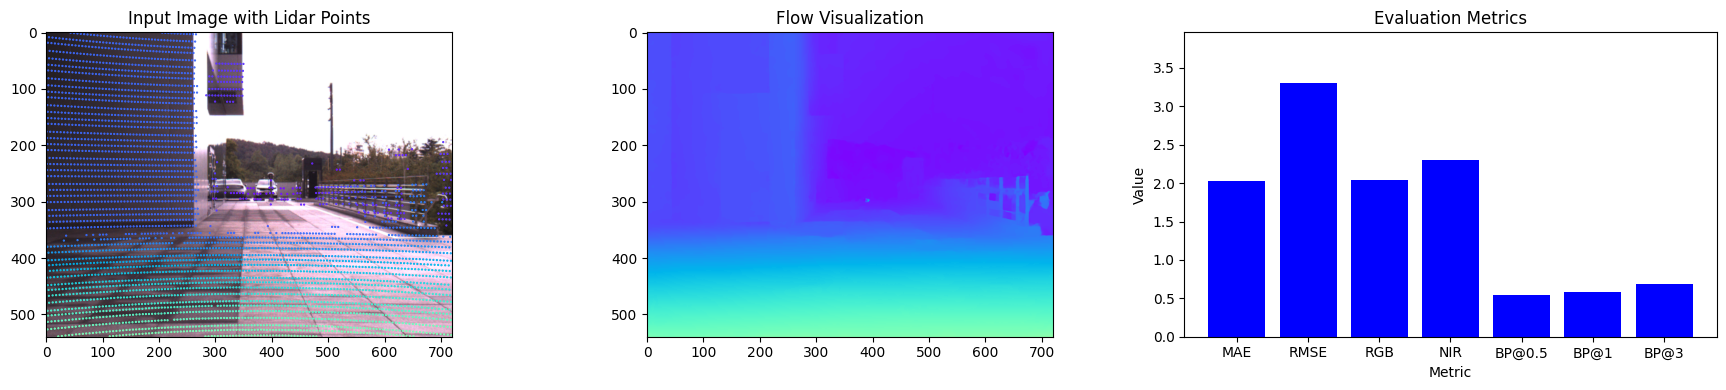

Opening frame 17_42_17_047 from /bean/depth/09-08-17-27-33/52.hdf5


KeyboardInterrupt: 

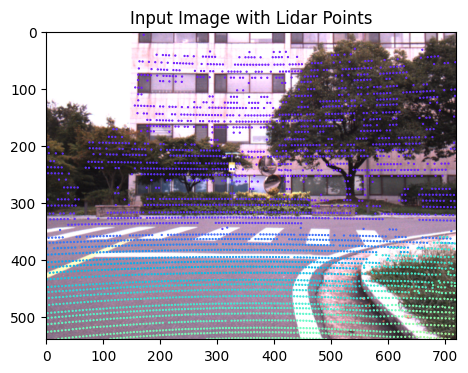

In [55]:
import random
add_frame("/bean/depth/09-08-17-27-33/17_27_33_189")

In [56]:
import json


print(len(frame_list))
#frame_list = random.sample(frame_list,50)
json.dump(frame_list,open("frames_day.json","w"))

209


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


MSCDepthModel(
  (netDisp_encode_RGB): ResnetEncoder(
    (encoder): ResNet(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (1): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
   

In [ ]:

FrameExplorer(plot_cross_sp_depth)

In [25]:
print(json.load(open("frames_night.json","r")))

['/bean/depth/09-28-21-15-50/21_21_47_925', '/bean/depth/09-28-21-15-50/21_32_13_525', '/bean/depth/09-28-21-15-50/21_25_45_125', '/bean/depth/09-28-21-15-50/21_20_34_725', '/bean/depth/09-28-21-15-50/21_29_04_725', '/bean/depth/09-28-21-15-50/21_17_26_725', '/bean/depth/09-28-21-15-50/21_30_22_125', '/bean/depth/09-28-21-15-50/21_25_42_925', '/bean/depth/09-28-21-15-50/21_17_58_525', '/bean/depth/09-28-21-15-50/21_31_19_125', '/bean/depth/09-28-21-15-50/21_23_31_925', '/bean/depth/09-28-21-15-50/21_29_58_725', '/bean/depth/09-28-21-15-50/21_18_28_925', '/bean/depth/09-28-21-15-50/21_35_23_525', '/bean/depth/09-28-21-15-50/21_25_20_725', '/bean/depth/09-28-21-15-50/21_16_06_325', '/bean/depth/09-28-21-15-50/21_33_25_925', '/bean/depth/09-28-21-15-50/21_20_54_725', '/bean/depth/09-28-21-15-50/21_33_55_525', '/bean/depth/09-28-21-15-50/21_20_35_125', '/bean/depth/09-28-21-15-50/21_21_53_125', '/bean/depth/09-28-21-15-50/21_16_17_725', '/bean/depth/09-28-21-15-50/21_21_08_725', '/bean/dep

In [49]:
import json
#json.dump(frames, open("frames_day.json","w"))
frames = [x for x in json.load(open("frames_indoor.json","r"))]


In [46]:
print(error_frame)


['/bean/depth/10-01-16-20-28/16_36_22_957', '/bean/depth/10-01-16-20-28/16_36_56_357']


In [33]:
from tqdm.notebook import tqdm

from train_fusion.dataloader import EntityDataSet


def ablation_test(data_prefix, frame_list, cnt = 50,  is_depth = True, steps = 15):
    if isinstance(frame_list, str):
        frame_list = json.load(open(frame_list, "r"))
    is_dataloader = isinstance(frame_list,EntityDataSet)
    fusion_args = FusionArgs()
    fusion_args.n_downsample = 2
    fusion_args.n_gru_layers = 3
    fusion_args.fusion = "AFF"
    fusion_args.shared_backbone = False
    fusion_args.shared_fusion = True
    fusion_args.alter_option = "Nir"

    ck = "checkpoints/latest_AFFAlterFnetShared.pth"

    w_dict = torch.load(ck)
    if "model_state_dict" in w_dict:
        w_dict = w_dict["model_state_dict"]
    mae_dict = {}
    rmse_dict = {}
    b_dict = {}
    ck_concat = "checkpoints/latest_ConcatAlterFnetShared.pth"
    w_dict_concat = torch.load(ck_concat)
    if "model_state_dict" in w_dict_concat:
        w_dict_concat = w_dict_concat["model_state_dict"]
    cnt = min(cnt, len(frame_list))

   

    error_frame = []

    def calculate_and_record_error(
        flow,
        flow_gt,
        lidar,
        is_depth,
        key_prefix,
        cnt,
        mae_dict,
        rmse_dict,
        b_dict,
        frame_path,
    ):
        if is_depth:
            flow = 864 * 0.134 / flow
            lidar = lidar[lidar[..., 2] > 2]
            n = lidar.shape[-2]
            sample_d = flow[..., lidar[..., 1].long(), lidar[..., 0].long()]
            d = 864 * 0.134 / lidar[..., 2]
            mae = torch.abs(sample_d - d).mean().item()
            rmse = torch.sqrt(torch.sum((sample_d - d) ** 2) / n).item()
            epe = torch.sqrt((sample_d - d) ** 2)
            bp1 = (epe < 0.5).float().mean().item()
            bp3 = (epe < 1).float().mean().item()
            bp5 = (epe < 3).float().mean().item()
        else:
            mask = (flow_gt < 100) & (flow_gt > 1)
            mae = torch.abs(flow[mask] - flow_gt[mask]).mean().item()
            rmse = torch.sqrt(((flow[mask] - flow_gt[mask]) ** 2).mean()).item()
            epe = torch.sqrt((flow[mask] - flow_gt[mask]) ** 2)
            bp1 = (epe < 1).float().mean().item()
            bp3 = (epe < 3).float().mean().item()
            bp5 = (epe < 5).float().mean().item()
        if key_prefix == "AFF_Nir":
            if rmse > 50:
                error_frame.append(frame_path)
            clear_output(wait=True)
            plt.figure(figsize=(10, 5))
            plt.subplot(1, 3, 1)
            plt.imshow(np.zeros_like(flow[0, 0].cpu().numpy()))
            plt.scatter(
                lidar[..., 0].cpu(),
                lidar[..., 1].cpu(),
                c=lidar[..., 2].cpu(),
                s=1,
                cmap="rainbow",
                vmin=0,
                vmax=64,
            )
            plt.title("Input Image with Lidar Points")

            # Subplot 2: Flow Image
            plt.subplot(1, 3, 2)
            plt.imshow(flow.cpu()[0, 0].numpy(), vmin=0, vmax=64, cmap="rainbow")
            plt.title("Flow Visualization")
            plt.subplot(1, 3, 3)
            metrics = [mae, rmse, bp1, bp3, bp5]
            metric_names = ["MAE", "RMSE", "BP@0.5", "BP@1", "BP@3"]
            plt.bar(metric_names, metrics, color="blue")
            plt.xlabel("Metric")
            plt.ylabel("Value")
            plt.title("Evaluation Metrics")
            plt.ylim(0, max(metrics) * 1.2)  # Set y limit to better visualize values

            # Show all subplots in one figure
            plt.tight_layout()
            plt.show()
            plt.clf()  # Clear the current figure to prevent overlapping plots in next iterations
            plt.close()  # Close the figure to free memory
        # 딕셔너리에 기록
        mae_dict[key_prefix] = mae_dict.get(key_prefix, []) + [mae]
        rmse_dict[key_prefix] = rmse_dict.get(key_prefix, []) + [rmse]
        b_dict[f"{key_prefix}_1px"] = b_dict.get(f"{key_prefix}_1px", []) + [bp1]
        b_dict[f"{key_prefix}_3px"] = b_dict.get(f"{key_prefix}_3px", []) + [bp3]
        b_dict[f"{key_prefix}_5px"] = b_dict.get(f"{key_prefix}_5px", []) + [bp5]

    for idx, batch in enumerate(range(cnt)):
        inputs = (
            [x.float().cuda() for x in get_valid_input_from_path(frame_list[batch * steps])]
            if isinstance(frame_list[batch], str)
            else [x.unsqueeze(0).cuda() for x in frame_list[batch* steps]]
        )
        # 에러 계산 및 딕셔너리 기록을 위한 함수 정의
        with torch.no_grad():
            flow_rgb = -raft_model(inputs[0], inputs[1], test_mode=True)[1]
            flow_nir = -raft_model(
                inputs[2].repeat(1, 3, 1, 1),
                inputs[3].repeat(1, 3, 1, 1),
                test_mode=True,
            )[1]
        flow_cres_rgb = predict_cres(inputs[0], inputs[1]).cuda()
        flow_cres_nir = predict_cres(
            inputs[2].repeat(1, 3, 1, 1), inputs[3].repeat(1, 3, 1, 1)
        ).cuda()
        print(f"{idx}/{cnt}")
        # flow_rgb와 flow_nir에 대한 에러 계산 및 기록
        for flow_name, flow in [
            ("RAFT-RGB", flow_rgb),
            ("RGB-NIR", flow_nir),
            ("CRES-RGB", flow_cres_rgb),
            ("CRES-NIR", flow_cres_nir),
        ]:
            calculate_and_record_error(
                flow=flow,
                flow_gt=inputs[-1],
                lidar=inputs[-2],
                is_depth=is_depth,
                key_prefix=f"{flow_name}",
                cnt=cnt,
                mae_dict=mae_dict,
                rmse_dict=rmse_dict,
                b_dict=b_dict,
                frame_path=frame_list[batch* steps] if not is_dataloader else None,
            )

        # i, j 루프 내에서의 에러 계산 및 기록
        for i, f in enumerate(["add", "ConCat", "bAFF", "AFF"]):
            for j, (alter, iters) in enumerate(
                [("Fusion", 18), ("Origin", 9), ("Mixed", 6), ("Nir", 9)]
            ):

                fusion_args.fusion = f
                fusion_args.alter_option = alter
                model = RAFTStereoFusionAlter(fusion_args).cuda()
                model.eval()
                model.load_state_dict(
                    w_dict_concat if f == "ConCat" else w_dict, strict=False
                )

                with torch.no_grad():
                    flow = -model(*inputs[:4], test_mode=True, iters=iters)[1]

                calculate_and_record_error(
                    flow=flow,
                    flow_gt=inputs[-1],
                    lidar=inputs[-2],
                    is_depth=is_depth,
                    key_prefix=f"{f}_{alter}",
                    cnt=cnt,
                    mae_dict=mae_dict,
                    rmse_dict=rmse_dict,
                    b_dict=b_dict,
                    frame_path=frame_list[batch] if not is_dataloader else None,
                )
    error_frame_filter = [x for x in error_frame if x in frame_list]
    error_indices = [frame_list.index(error) for error in error_frame_filter]
    error_indices.sort(reverse=True)
    n_result = {}
    for label, l_dict in [("mae", mae_dict), ("rmse", rmse_dict), ("b", b_dict)]:
        n_dict = {}
        for k, v in l_dict.items():
            for idx in error_indices:
                del v[idx]
            v = np.asarray(v)
            n_dict[k] = float(np.mean(v[~np.isinf(v)]))
        n_result[label] = n_dict
    json.dump(n_result, open(f"abl_{data_prefix}.json","w"))

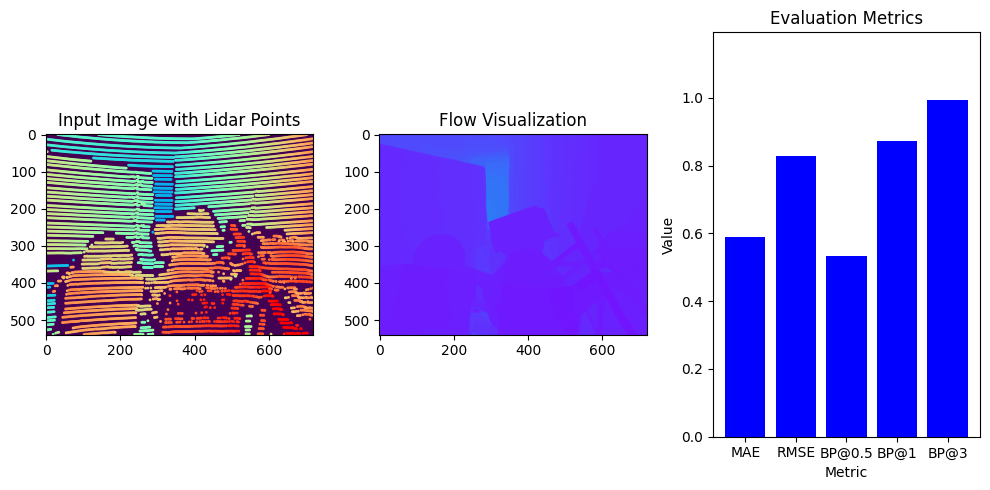

In [34]:

ablation_test("synth_data", dataset_synth, cnt = 200, is_depth=False)
ablation_test("day", "frames_day.json", cnt = 100, is_depth=True,steps=1)
ablation_test("night", "frames_night.json", cnt = 100, is_depth=True,steps=1)
ablation_test("indoor", "frames_indoor.json", cnt = 100, is_depth=True,steps=1)



In [51]:
error_frame_filter = [x for x in error_frame if x in frame_list]
error_indices = [frame_list.index(error) for error in error_frame_filter]
error_indices.sort(reverse=True)
for l_dict in [mae_dict, rmse_dict, b_dict]:
    n_dict = {}
    for k,v in l_dict.items():
        for idx in error_indices:
            del v[idx]
        v = np.asarray(v)
        n_dict[k] = float(np.mean(v[~np.isinf(v)]))
    print(n_dict)

{'RAFT-RGB': 0.9586181241646409, 'RGB-NIR': 0.8137459073960781, 'CRES-RGB': 0.8183766095340252, 'CRES-NIR': 0.7869706390053034, 'add_Fusion': 0.7824796904623509, 'add_Origin': 0.7609970832616091, 'add_Mixed': 0.7336265555024147, 'add_Nir': 0.7599974266439676, 'ConCat_Fusion': 0.8229392233490944, 'ConCat_Origin': 0.826440197750926, 'ConCat_Mixed': 0.7419560109823942, 'ConCat_Nir': 0.7773204113543034, 'bAFF_Fusion': 0.7534525546431542, 'bAFF_Origin': 0.7596477857977152, 'bAFF_Mixed': 0.7287638401985168, 'bAFF_Nir': 0.7534445668756962, 'AFF_Fusion': 0.7789539974182844, 'AFF_Origin': 0.7620767586678266, 'AFF_Mixed': 0.7461970964819193, 'AFF_Nir': 0.7647968200594186}
{'RAFT-RGB': 1.697011323198676, 'RGB-NIR': 1.436580104380846, 'CRES-RGB': 1.2799080695956946, 'CRES-NIR': 1.411429074779153, 'add_Fusion': 1.665871623158455, 'add_Origin': 1.4782883390784263, 'add_Mixed': 1.3586143758893012, 'add_Nir': 1.6779271323978902, 'ConCat_Fusion': 1.5549330469965934, 'ConCat_Origin': 4.6669304749369624,

In [160]:
print(mae_dict)
print(rmse_dict)
print(b_dict)

{'flow_rgb': [2.977433919906616, 4.391707897186279, 5.07988166809082, 2.8118975162506104, 2.025944709777832, 2.020885467529297, 0.7885218262672424, 4.492034435272217, 4.5949835777282715, 1.899056077003479, 1.9643936157226562, 2.640267848968506, 2.0498714447021484, 4.48642635345459, 1.1766891479492188, 4.911764621734619, 4.795694351196289, 9.891629219055176, 3.7971885204315186, 5.6604461669921875, 4.83790397644043, 2.3752856254577637, 1.7055919170379639, 2.6478683948516846, 2.986923933029175, 4.527444839477539, 2.211400270462036, 5.272896766662598, 3.935823917388916, 1.332107424736023, 2.1203460693359375, 7.251272678375244, 2.0997836589813232, 3.792084217071533, 1.6260050535202026, 3.8640499114990234, 1.6891547441482544, 4.9265618324279785, 3.4551777839660645, 2.957737684249878, 1.2933403253555298, 2.9906671047210693, 3.6234211921691895, 4.996583938598633, 4.19329309463501, 5.071364402770996, 2.0455493927001953, 3.4103362560272217, 1.417162537574768], 'flow_nir': [2.3423826694488525, 5.

In [151]:
print(error_frame)

['/bean/depth/09-08-17-27-33/17_32_20_605']


In [24]:
import pfmread
from train_fusion.dataloader import EntityFlying3d
def get_object_bounding_box(object_index:np.ndarray):
    object_index[object_index > 288] = 0
    object_index[object_index < 240] = 0
    _, mask = cv2.threshold(object_index, 1, 1024, cv2.THRESH_BINARY)
    mask[mask > 0] = 1
    contours, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    return [cv2.boundingRect(contour) for contour in contours]


def get_object_bounding_from_entity(entity: EntityFlying3d):
    key_path = entity.images[0].split("/")[3]
    removal = entity.images[0].replace(key_path,"object_index").split("_")[-1]

    path_object_index = entity.images[0].replace(key_path,"object_index").replace("_"+removal,".pfm")
    object_index = pfmread.read(path_object_index)
    bounding_box = get_object_bounding_box(object_index)
    return bounding_box

def od_test_item(entity: EntityFlying3d):
    bounding_box = get_object_bounding_from_entity(entity)
    image_rgb = torch.from_numpy(cv2.imread(entity.images[0])).permute(2,0,1).float()
    image_nir = torch.from_numpy(cv2.imread(entity.images[2])).permute(2,0,1).float()
    bounding_box = torch.from_numpy(np.asarray(bounding_box))
    print(bounding_box.shape)
    return image_rgb, image_nir, bounding_box
def od_test_item2(entity: EntityFlying3d):
    image_rgb, image_nir, bounding_box = od_test_item(entity)
    return [
        image_rgb.unsqueeze(0)[...,120:120+720],
        image_rgb.unsqueeze(0)[...,120:120+720],
        image_nir[:1].unsqueeze(0)[...,120:120+720],
        image_nir[:1].unsqueeze(0)[...,120:120+720],
        
    ], bounding_box
    

In [25]:
import torch
from scipy.optimize import linear_sum_assignment

def iou(box1, box2):
    """
    Calculate the Intersection over Union (IoU) between two bounding boxes.
    box1: Tensor of shape (4,) representing [x, y, w, h]
    box2: Tensor of shape (4,) representing [x, y, w, h]
    """
    x1_min = box1[0]
    y1_min = box1[1]
    x1_max = box1[0] + box1[2]
    y1_max = box1[1] + box1[3]

    x2_min = box2[0]
    y2_min = box2[1]
    x2_max = box2[0] + box2[2]
    y2_max = box2[1] + box2[3]

    # Intersection coordinates
    inter_x_min = max(x1_min, x2_min)
    inter_y_min = max(y1_min, y2_min)
    inter_x_max = min(x1_max, x2_max)
    inter_y_max = min(y1_max, y2_max)

    inter_area = max(0, inter_x_max - inter_x_min) * max(0, inter_y_max - inter_y_min)
    box1_area = box1[2] * box1[3]
    box2_area = box2[2] * box2[3]

    union_area = box1_area + box2_area - inter_area
    return inter_area / union_area if union_area > 0 else 0

def hungarian_loss(pred_boxes, target_boxes):
    """
    Compute the loss using Hungarian Algorithm for matching.
    pred_boxes: Tensor of shape (m, 4) representing predicted bounding boxes
    target_boxes: Tensor of shape (n, 4) representing ground truth bounding boxes
    """
    m, n = pred_boxes.size(0), target_boxes.size(0)

    # Calculate IoU matrix
    iou_matrix = torch.zeros((m, n))
    for i in range(m):
        for j in range(n):
            iou_matrix[i, j] = iou(pred_boxes[i], target_boxes[j])

    # Use Hungarian Algorithm to find the best matching
    iou_matrix = iou_matrix.numpy()
    row_ind, col_ind = linear_sum_assignment(-iou_matrix)  # Maximize IoU

    # Compute Localization Loss (Smooth L1 Loss)
    loss = 0
    for i, j in zip(row_ind, col_ind):
        if iou_matrix[i, j] > 0:  # Only consider valid matches
            loss += torch.nn.functional.smooth_l1_loss(pred_boxes[i], target_boxes[j])

    # Normalize loss by the number of matches
    return loss / len(row_ind) if len(row_ind) > 0 else torch.tensor(0.0)

torch.Size([26, 4])

0: 384x640 2 trucks, 157.5ms
Speed: 4.2ms preprocess, 157.5ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)
tensor(82.1669, device='cuda:0')


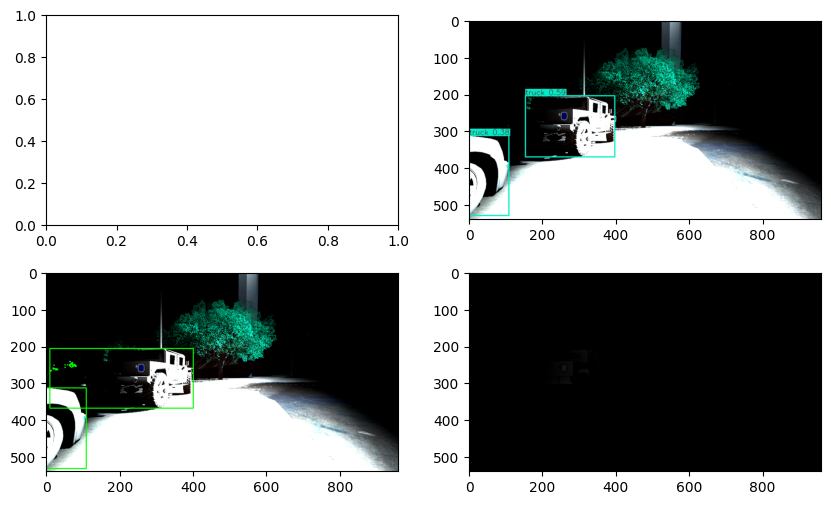

In [30]:
from matplotlib.contour import ContourSet
import torch
import pfmread
import numpy as np
import matplotlib.pyplot as plt
import cv2
path = "/bean/flow3d/normal_map/15mm_focallength/scene_forwards/fast/left/0011.pfm"

image_rgb, image_nir, contours  = od_test_item(dataset_drive.input_list[55])


plt.figure(figsize=(10, 6))
plt.subplot(2,2,1)

plt.subplot(2,2,2)
#plt.imshow(object_index, cmap="jet")
#plt.colorbar()
#plt.subplot(2,2,3)


#plt.colorbar()
image_rgb = image_rgb.permute(1,2,0).numpy().astype(np.uint8)
n = contours.shape[0]

from ultralytics import YOLO
yolo_model = YOLO('yolov8n.pt')  
output = yolo_model(image_rgb)
plt.subplot(2,2,2)
boxes = torch.stack([x for x in output[0].boxes.xywh], dim=0)

loss = hungarian_loss(boxes, contours.cuda())
print(loss)
plt.imshow(output[0].plot())
for i in range(n):
    x, y, w, h = [int(x) for x in contours[i]]

    
    cv2.rectangle(image_rgb, (x, y), (x+w, y+h), (0, 255, 0), 2)
    #cv2.drawContours(image_rgb, contour, -1, (255, 255, 255), 2)
    
plt.subplot(2,2,3)
plt.imshow(image_rgb)
plt.subplot(2,2,4)

plt.imshow(image_nir.permute(1,2,0).numpy().astype(np.uint8))


plt.show()


In [29]:
def compute_yolo(image, contours):
    output = yolo_model(image)
    try:
        boxes = torch.stack([x for x in output[0].boxes.xywh], dim=0)
        loss = hungarian_loss(boxes, contours.cuda()).cpu().item()
    except Exception:
        loss = 250
    return loss, output[0].plot()

inputs, boxes = od_test_item2(dataset_drive.input_list[55])

fusion_dict = comparison_study_color(inputs)

h = len(fusion_dict.keys())
print(h)
plt.figure(figsize=(48,6))
losses = []
for i, (k,v) in enumerate(fusion_dict.items()):
    img = v[0].unsqueeze(0)
    img = F.pad(img / 255, (0,16,0,4))
    loss, img = compute_yolo(img, boxes)
    losses.append(loss)
    plt.subplot(1,h+1,1 + i)
    plt.title(k)
    plt.imshow(img)
plt.subplot(1,h+1,1 + h)
plt.bar(fusion_dict.keys(),losses,)

plt.show()
    
    


torch.Size([26, 4])
7


/tmp/ipykernel_3665206/769712033.py:14: RuntimeWarning: divide by zero encountered in divide
  m = (l - lt) / l
/tmp/ipykernel_3665206/769712033.py:14: RuntimeWarning: invalid value encountered in divide
  m = (l - lt) / l


NameError: name 'yolo_model' is not defined

<Figure size 4800x600 with 0 Axes>

10044



0: 544x736 (no detections), 8.6ms
Speed: 1.2ms preprocess, 8.6ms inference, 1.3ms postprocess per image at shape (1, 3, 544, 736)

0: 544x736 1 mouse, 8.5ms
Speed: 1.1ms preprocess, 8.5ms inference, 2.1ms postprocess per image at shape (1, 3, 544, 736)

0: 544x736 (no detections), 8.4ms
Speed: 1.2ms preprocess, 8.4ms inference, 1.2ms postprocess per image at shape (1, 3, 544, 736)

0: 544x736 (no detections), 8.5ms
Speed: 1.1ms preprocess, 8.5ms inference, 1.3ms postprocess per image at shape (1, 3, 544, 736)

0: 544x736 (no detections), 8.5ms
Speed: 1.2ms preprocess, 8.5ms inference, 1.2ms postprocess per image at shape (1, 3, 544, 736)

0: 544x736 (no detections), 8.5ms
Speed: 1.1ms preprocess, 8.5ms inference, 1.3ms postprocess per image at shape (1, 3, 544, 736)

0: 544x736 (no detections), 8.2ms
Speed: 0.0ms preprocess, 8.2ms inference, 1.0ms postprocess per image at shape (1, 3, 544, 736)


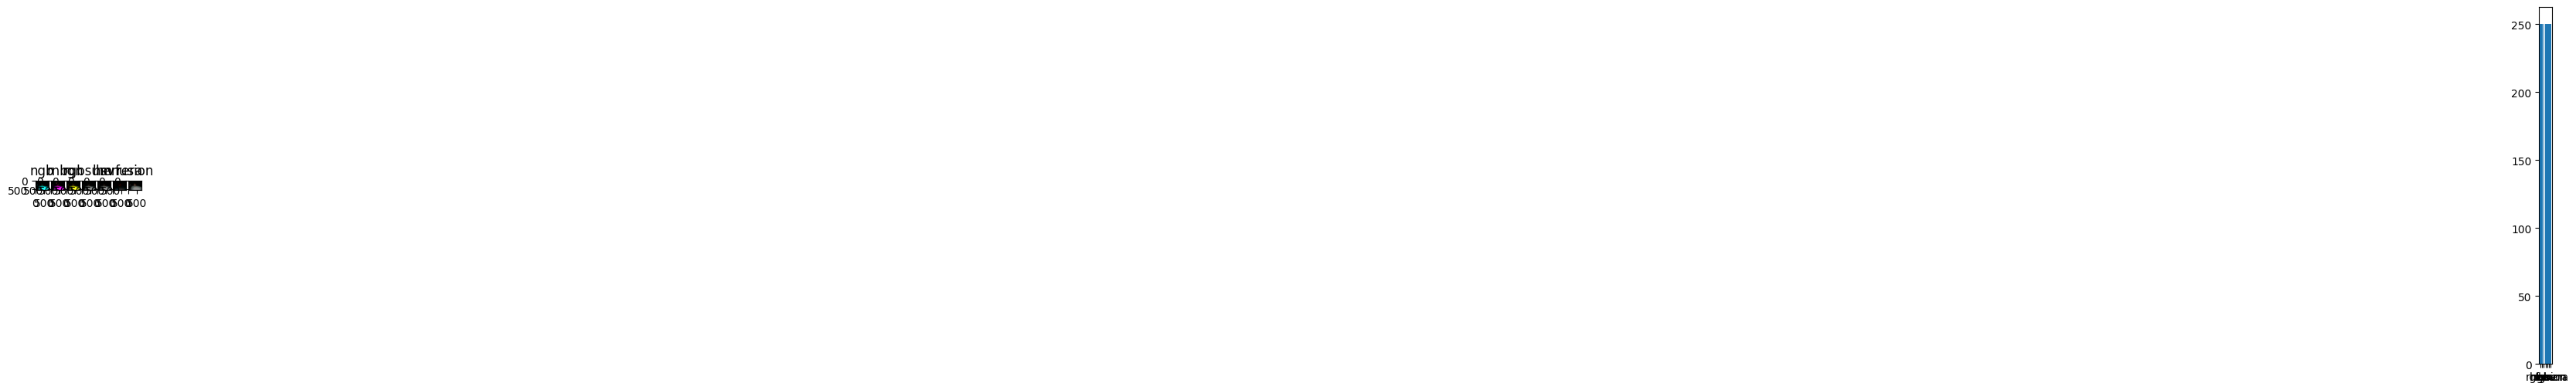

In [31]:
from IPython.display import clear_output
import json
loss_dict = {}
cnt = 1000
for b in range(cnt):
    inputs, boxes = od_test_item2(dataset_drive.input_list[b*10])
    print(f"{b}/{cnt}")
    fusion_dict = comparison_study_color(inputs)
    losses = []
    clear_output(wait=True)
    plt.figure(figsize=(42,6))
    for i, (k,v) in enumerate(fusion_dict.items()):
        img = v[0].unsqueeze(0)
        img = F.pad(img / 255, (0,16,0,4))
        loss, img = compute_yolo(img, boxes)
        if not k in loss_dict:
            loss_dict[k] = []
        loss_dict[k].append(loss)
        losses.append(loss)
        plt.subplot(1,h+1,1 + i)
        plt.title(k)
        plt.imshow(img)
    plt.subplot(1,h+1,1 + h)
    plt.bar(fusion_dict.keys(),losses,)
    plt.show()
    
        

avg_dict = {}
for k,v in loss_dict.items():
    avg_dict[k] = np.mean(v)

json.dump({
    "loss":loss_dict,
    "avg_loss": avg_dict,
}, open("comparison_synth_od.json","w"))

